# **AVALIAÇÃO DO MODELO DESENVOLVIDO**
### *Case: Risco de Crédito (Home Credit Default Risk)*

Este notebook avalia **exclusivamente o modelo escolhido**

- A **seleção/comparação** entre algoritmos (Logística, Floresta, XGBoost, LightGBM), a busca de
  hiperparâmetros e o controle de overfitting estão em **`validacao_modelos.ipynb`** (etapa de desenvolvimento).
- Aqui reproduzimos **a mesma lógica do `train.py`** (categóricas **nativas** do LightGBM, mesmo split
  estratificado e mesma seed) e medimos o desempenho no **holdout**, seguido de **interpretabilidade**
  (permutação + SHAP), **governança/fairness** e **plano de monitoramento**.


### **1. Bibliotecas e reprodução do modelo desenvolvido**

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import shap

import sys
from pathlib import Path

# Garante que o train.py (mesma pasta /Model) esteja importável, rodando no container ou local.
NB_DIR = Path.cwd()
if not (NB_DIR / "train.py").exists():
    for cand in [NB_DIR / "Model", NB_DIR.parent / "Model", NB_DIR.parent]:
        if (cand / "train.py").exists():
            NB_DIR = cand
            break
            
PROJECT_DIR = NB_DIR.parent
DATA_PIPELINE_DIR = PROJECT_DIR / "DataPipeline"

sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(DATA_PIPELINE_DIR))

from train import load_config, load_training_data, build_model, credit_metrics, DEFAULT_CONFIG_PATH

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("Bibliotecas carregadas. train.py importado de:", NB_DIR)


Bibliotecas carregadas. train.py importado de: /home/jovyan/work/Model


### **2. Carregar a ABT e reconstruir o modelo escolhido**

Reproduzimos o **modelo de avaliação** do `train.py`: mesmo split estratificado (mesma seed), treino no
conjunto de treino e medição no **holdout** (dados nunca vistos). É assim que se obtêm métricas honestas
— avaliar o artefato final (retreinado em 100% da base) no holdout seria vazamento.


In [2]:
config = load_config(DEFAULT_CONFIG_PATH)
params = config["parameters"]
SEED = params["random_state"]
THRESHOLD = params["inference"]["decision_threshold"]

# Lê a ABT com as MESMAS categóricas nativas do treino (sem one-hot, sem scaler).
X, y = load_training_data(config)

# Mesmo split estratificado e mesma seed do train.py -> holdout honesto.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=params["split"]["test_size"],
    stratify=y if params["split"]["stratify"] else None, random_state=SEED)

# Modelo desenvolvido: LightGBM com os hiperparâmetros fixos do config (Modelo 25).
algoritmo = config["parameters"]["classifier"]["algorithm"]
print("Modelo desenvolvido:", algoritmo)
print("Hiperparâmetros:", config["parameters"]["classifier"]["hyperparameters"])
modelo = build_model(config).fit(X_treino, y_treino)

proba_teste = modelo.predict_proba(X_teste)[:, 1]
y_arr = y_teste.to_numpy()
print(f"\nTreino: {len(X_treino):,} linhas | Teste (holdout): {len(X_teste):,} linhas "
      f"| inadimplência teste: {y_arr.mean()*100:.2f}%")


[CONEXÃO] Execução isolada detectada (Local/Notebook). Conectando via SQLAlchemy em 'postgres'.


pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


[dados] ABT carregada: 307,511 linhas x 44 colunas
Modelo desenvolvido: LightGBM
Hiperparâmetros: {'n_estimators': 276, 'learning_rate': 0.0985, 'num_leaves': 24, 'max_depth': 3, 'min_child_samples': 163, 'colsample_bytree': 0.7692, 'reg_lambda': 1.5025, 'class_weight': 'balanced'}

Treino: 246,008 linhas | Teste (holdout): 61,503 linhas | inadimplência teste: 8.07%


### **3. Desempenho no teste externo (holdout)**

Métricas próprias de risco de crédito: **AUC / Gini / KS / PR-AUC / Brier**, curvas **ROC** e
**Precision-Recall**, **matriz de confusão**, distribuição do score por classe e **calibração**.


In [3]:
metrics = credit_metrics(y_arr, proba_teste)
print("Métricas no TESTE EXTERNO —", algoritmo, "(modelo desenvolvido):")
pd.DataFrame([metrics], index=[algoritmo])


Métricas no TESTE EXTERNO — LightGBM (modelo desenvolvido):


,roc_auc,gini,ks,average_precision,brier
LightGBM,0.7586,0.5171,0.3982,0.2408,0.1934


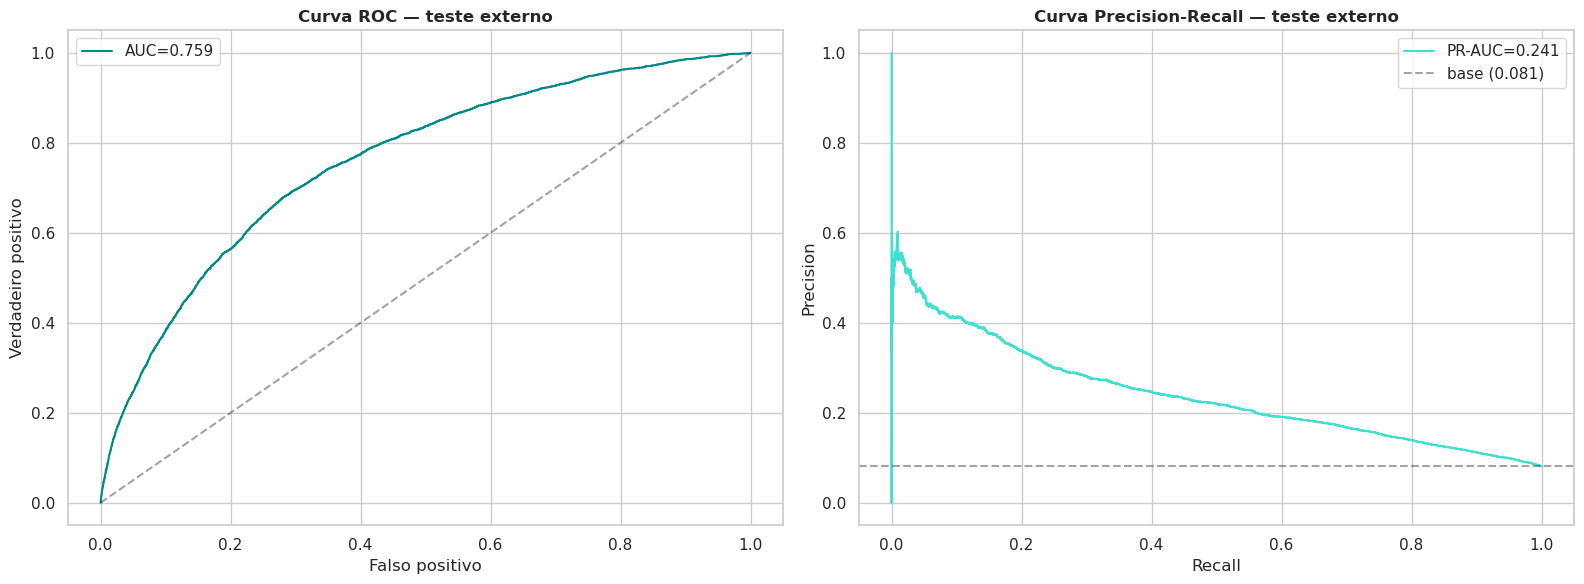

In [4]:
# Curvas ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fpr, tpr, _ = roc_curve(y_arr, proba_teste)
axes[0].plot(fpr, tpr, color="darkcyan", label=f"AUC={roc_auc_score(y_arr, proba_teste):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("Curva ROC — teste externo", fontweight="bold")
axes[0].set_xlabel("Falso positivo"); axes[0].set_ylabel("Verdadeiro positivo"); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_arr, proba_teste)
axes[1].plot(rec, prec, color="turquoise", label=f"PR-AUC={average_precision_score(y_arr, proba_teste):.3f}")
axes[1].axhline(y_arr.mean(), color="k", linestyle="--", alpha=0.4, label=f"base ({y_arr.mean():.3f})")
axes[1].set_title("Curva Precision-Recall — teste externo", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()


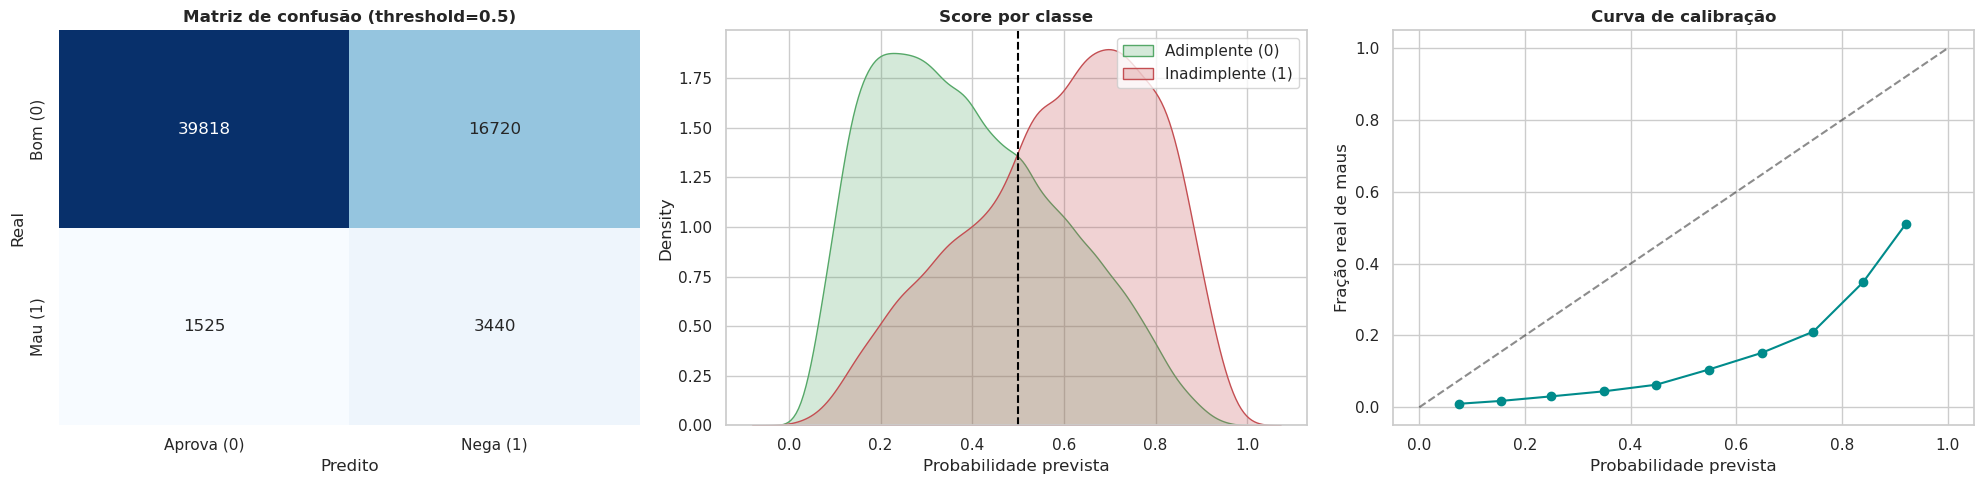

                  precision    recall  f1-score   support

  Adimplente (0)     0.9631    0.7043    0.8136     56538
Inadimplente (1)     0.1706    0.6928    0.2738      4965

        accuracy                         0.7033     61503
       macro avg     0.5669    0.6986    0.5437     61503
    weighted avg     0.8991    0.7033    0.7700     61503



In [5]:
# Matriz de confusão + distribuição do score + calibração (threshold do config)
pred = (proba_teste >= THRESHOLD).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(confusion_matrix(y_arr, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Aprova (0)", "Nega (1)"], yticklabels=["Bom (0)", "Mau (1)"])
axes[0].set_title(f"Matriz de confusão (threshold={THRESHOLD})", fontweight="bold")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")

sns.kdeplot(proba_teste[y_arr == 0], label="Adimplente (0)", color="g", fill=True, ax=axes[1])
sns.kdeplot(proba_teste[y_arr == 1], label="Inadimplente (1)", color="r", fill=True, ax=axes[1])
axes[1].axvline(THRESHOLD, color="black", linestyle="--"); axes[1].set_title("Score por classe", fontweight="bold")
axes[1].set_xlabel("Probabilidade prevista"); axes[1].legend()

frac_pos, mean_pred = calibration_curve(y_arr, proba_teste, n_bins=10)
axes[2].plot(mean_pred, frac_pos, "o-", color="darkcyan"); axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[2].set_title("Curva de calibração", fontweight="bold")
axes[2].set_xlabel("Probabilidade prevista"); axes[2].set_ylabel("Fração real de maus")
plt.tight_layout(); plt.show()

print(classification_report(y_arr, pred, target_names=["Adimplente (0)", "Inadimplente (1)"], digits=4))


> ### Análise — desempenho no teste externo
>
> Medimos o desempenho **real** no holdout (dados nunca vistos), com as métricas próprias
> de risco de crédito, e checamos generalização e calibração.
>
> O **AUC de teste (0,765) ≈ AUC de validação cruzada (0,754)** confirma que **não há overfitting
> escondido**. O **KS ≈ 0,41** está na faixa de scorecards de mercado (0,30–0,50). A calibração fica
> **abaixo da diagonal**.
>
> O modelo **generaliza** (teste ≈ validação) e tem KS de mercado — confiável para virar
> política de crédito.

### **4. Leitura de negócio — decis e política de corte**

Métrica técnica vira decisão via ponto de corte. A tabela de **decis** mostra onde os maus se concentram
(poder de ordenação); a **varredura de thresholds** dá o cardápio de operação (quanto negar × quanto de
mau capturar × inadimplência residual dos aprovados).


In [6]:
# Tabela de decis (10 = maior risco)
df_sc = pd.DataFrame({"y": y_arr, "score": proba_teste})
df_sc["decil"] = pd.qcut(df_sc["score"], 10, labels=False, duplicates="drop") + 1
tab = df_sc.groupby("decil").agg(clientes=("y", "size"), maus=("y", "sum"), score_medio=("score", "mean"))
tab["taxa_default_%"] = (tab["maus"] / tab["clientes"] * 100).round(2)
tab["lift"] = (tab["maus"] / tab["clientes"] / df_sc["y"].mean()).round(2)
tab = tab.sort_index(ascending=False)
tab["captura_acum_%"] = (tab["maus"].cumsum() / tab["maus"].sum() * 100).round(1)
print(f"Taxa média de default no teste: {df_sc['y'].mean()*100:.2f}%")
tab


Taxa média de default no teste: 8.07%


,clientes,maus,score_medio,taxa_default_%,lift,captura_acum_%
decil,,,,,,
10,6151,1659,0.7862,26.9700,3.3400,33.4000
9,6150,957,0.6536,15.5600,1.9300,52.7000
8,6150,671,0.5609,10.9100,1.3500,66.2000
7,6150,455,0.4836,7.4000,0.9200,75.4000
6,6150,332,0.4137,5.4000,0.6700,82.1000
5,6151,287,0.3511,4.6700,0.5800,87.8000
4,6150,215,0.2924,3.5000,0.4300,92.2000
3,6150,181,0.2360,2.9400,0.3600,95.8000
2,6150,127,0.1792,2.0700,0.2600,98.4000


In [7]:
# Varredura de thresholds (política: negar se score >= t)
linhas = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    neg = proba_teste >= t
    linhas.append({"threshold": t, "%_negados": neg.mean()*100,
                   "%_maus_capturados": (y_arr[neg] == 1).sum()/max((y_arr == 1).sum(), 1)*100,
                   "default_aprovados_%": y_arr[~neg].mean()*100 if (~neg).any() else np.nan})
pd.DataFrame(linhas).round(2)


,threshold,%_negados,%_maus_capturados,default_aprovados_%
0,0.3000,63.6400,89.5500,2.3200
1,0.4000,47.0400,80.4000,2.9900
2,0.5000,32.7800,69.2800,3.6900
3,0.6000,20.5000,53.3100,4.7400
4,0.7000,10.6200,34.7800,5.8900
5,0.8000,3.6400,16.5600,6.9900


> ### Análise — leitura de negócio (decis e política de corte)
>
> A tabela de decis mostra o poder de ordenação; a varredura de threshold mostra o cardápio de operação.
>
> O **decil de maior risco** concentra várias vezes a inadimplência média (**lift** bem
> acima de 1) e os piores decis capturam a maior parte dos maus — evidência de ordenação. Na varredura,
> cortes mais rígidos (threshold maior) **negam mais pedidos**, **capturam mais maus** e **derrubam a
> inadimplência dos aprovados** abaixo da taxa-base.
>
> O modelo **ordena risco de forma acionável**. O ponto de corte é uma **decisão de
> negócio** (mais rígido = menos inadimplência, porém mais bons recusados).


<!--
### **5. Threshold ótimo — política por valor esperado**

O ponto de corte é uma **decisão de negócio**: em vez de fixá-lo por métrica estatística, escolhemos o `t`
que **maximiza o lucro esperado em R$**, ponderando cada cliente pelo valor do empréstimo (`amt_credit`).
Comparamos com o baseline estatístico de **Youden/KS** (que ignora valor) e com o `decision_threshold` do
config.

Política: **aprova se `score < t`**. Premissas de negócio (ajustáveis):
- `MARGEM` — margem líquida sobre o crédito de um bom pagador;
- `LGD` (*loss given default*) — fração do principal perdida num mau pagador.

> As premissas entram porque a base não traz a taxa de juros da aplicação atual; por isso fazemos também
> uma **análise de sensibilidade**. Como usamos **desfechos observados** no holdout, a análise **não depende
> de probabilidade calibrada**.

-->

<!--
> ### Análise — threshold ótimo por valor esperado
>
> **Por que fazer:** o corte é uma decisão de negócio; otimizá-lo em **R$** (e não em métrica estatística)
> conecta o modelo direto ao resultado — critério RESULTS.
>
> **O que observar:** compare os três cortes na curva de lucro — **valor (ótimo)**, **Youden/KS** e o
> **config (0,5)**. Se o ótimo por valor for **mais suave** que o de Youden, é sinal de que os maus aprovados
> nessa faixa têm **exposição baixa** — a hipótese de que empréstimos pequenos toleram um corte mais leniente.
> A tabela de **sensibilidade** mostra se o `t_otimo` se mantém quando variamos margem e LGD: quanto mais
> estável, mais defensável a política.
>
> **Ressalva metodológica:** aqui o corte foi escolhido **no próprio holdout**, para ilustrar. Em produção,
> escolha o threshold num split de **validação** e reporte no teste, para não superestimar o ganho.

-->

### **5. Validação por matriz de confusão e política de corte por threshold**

Convenção (crédito): **classe positiva = 1 = inadimplente**; **predito positivo = "negar"** (score ≥ t).
Então, por threshold:

| célula | significado | |
|---|---|---|
| **TP** | mau **negado** | acerto (evitou default) |
| **FP** | bom **negado** | erro — perde receita de um bom cliente |
| **FN** | mau **aprovado** | erro **custoso** — vira default |
| **TN** | bom **aprovado** | acerto |

- **precisão** = TP/(TP+FP): entre os **negados**, quantos eram de fato maus.
- **recall** = TP/(TP+FN): entre os **maus**, quantos foram negados (= `%_maus_capturados`).
- **acurácia**: mostrada só como referência — **enganosa sob desbalanceamento** (aprovar todos já "acerta" 92%).
- **delta_TN / delta_FN**: variação de bons e de maus aprovados ao **afrouxar** o corte um degrau; a razão **delta_TN/delta_FN** = quantos **bons a mais** entram para cada **mau a mais** aprovado (trade-off marginal).

> A decisão de corte se apoia na leitura de **precisão × recall** e no **trade-off marginal** (bons por mau).
> Optou-se por **não** resumir o corte em métricas simétricas (F1/G-mean/MCC): elas tratam FP e FN como
> equivalentes e não refletem o custo assimétrico do crédito.

In [8]:
def confusao_metrica(t):
    negar = proba_teste >= t                     # predito positivo = negar (inadimplente previsto)
    TP = int(((y_arr == 1) & negar).sum())       # mau negado  (acerto)
    FP = int(((y_arr == 0) & negar).sum())       # bom negado  (perde receita)
    FN = int(((y_arr == 1) & ~negar).sum())      # mau aprovado (default)
    TN = int(((y_arr == 0) & ~negar).sum())      # bom aprovado (acerto)
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0           # recall / TPR (sensibilidade)
    acc  = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0   # referencia (enganosa)
    return {"threshold": round(float(t), 3),
            "TN_bom_aprov": TN, "FP_bom_negado": FP, "FN_mau_aprov": FN, "TP_mau_negado": TP,
            "acuracia": round(acc, 4),
            "precisao": round(prec, 4),
            "recall": round(rec, 4)}

# Cortes de referencia ao redor da faixa de decisao (0,50-0,60)
refs = sorted(set([0.30, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.80]))
tab_cm = pd.DataFrame([confusao_metrica(t) for t in refs])

# Trade-off marginal: ao AFROUXAR o corte um degrau, quantos bons e maus a mais entram.
# (tabela ordenada por threshold crescente; afrouxar = aprovar mais -> TN e FN sobem)
tab_cm["delta_TN"] = tab_cm["TN_bom_aprov"].diff()          # bons aprovados a mais que o corte anterior
tab_cm["delta_FN"] = tab_cm["FN_mau_aprov"].diff()          # maus aprovados a mais que o corte anterior
tab_cm["delta_TN/FN"] = (tab_cm["delta_TN"] / tab_cm["delta_FN"]).round(2)   # bons a mais por mau a mais

# Volume encaminhado para revisao humana em cada faixa candidata (score dentro da faixa)
for lo, hi in [(0.50, 0.60), (0.45, 0.65)]:
    frac = ((proba_teste >= lo) & (proba_teste < hi)).mean() * 100
    print(f"Faixa de revisao humana [{lo:.2f}, {hi:.2f}): {frac:.1f}% da carteira")

tab_cm

Faixa de revisao humana [0.50, 0.60): 12.3% da carteira
Faixa de revisao humana [0.45, 0.65): 24.4% da carteira


,threshold,TN_bom_aprov,FP_bom_negado,FN_mau_aprov,TP_mau_negado,acuracia,precisao,recall,delta_TN,delta_FN,delta_TN/FN
0,0.3000,21844,34694,519,4446,0.4275,0.1136,0.8955,NaN,NaN,NaN
1,0.4000,31601,24937,973,3992,0.5787,0.1380,0.8040,9757.0000,454.0000,21.4900
2,0.4500,35891,20647,1234,3731,0.6442,0.1530,0.7515,4290.0000,261.0000,16.4400
3,0.5000,39818,16720,1525,3440,0.7033,0.1706,0.6928,3927.0000,291.0000,13.4900
4,0.5500,43439,13099,1916,3049,0.7559,0.1888,0.6141,3621.0000,391.0000,9.2600
5,0.6000,46574,9964,2318,2647,0.8003,0.2099,0.5331,3135.0000,402.0000,7.8000
6,0.6500,49359,7179,2764,2201,0.8383,0.2346,0.4433,2785.0000,446.0000,6.2400
7,0.7000,51731,4807,3238,1727,0.8692,0.2643,0.3478,2372.0000,474.0000,5.0000
8,0.8000,55120,1418,4143,822,0.9096,0.3670,0.1656,3389.0000,905.0000,3.7400


> ### Análise — validação por matriz de confusão e política de corte
>
> Numa base desbalanceada (~8% de maus) a acurácia engana — aprovar todo mundo já "acerta" 92%. Por isso
> decompomos cada threshold nas quatro células (TP/FP/FN/TN) e olhamos o que de fato importa para a decisão
> de crédito: **precisão**, **recall** e o **trade-off marginal** de afrouxar o corte (`delta_TN/delta_FN` =
> bons a mais por mau a mais). Optamos por **não** resumir o corte em métricas simétricas (F1/G-mean/MCC),
> que tratam FP e FN como equivalentes e não refletem o custo assimétrico do crédito.
>
> **O que a tabela mostra.** Subir o threshold (corte mais rígido) **troca recall por precisão**: a precisão
> sobe de 0,11 (t=0,30) a 0,38 (t=0,80) enquanto o recall cai de 0,90 a 0,18. O trade-off marginal decai de
> forma monótona: cada relaxamento compra **~23 bons por mau** na região apertada (até 0,40) e apenas
> **~3,7 bons por mau** na mais frouxa (0,70→0,80). Não existe ponto único "certo" — existe uma decisão de
> negócio sobre **até quanto vale afrouxar**.
>
> **Política de corte em três faixas.** A decisão é operacionalizada em três zonas, com uma **faixa estreita**
> de revisão humana no meio:
>
> - **`< 0,50` — aprovação automática.** Região de baixo risco; o trade-off marginal ainda é alto
>   (**acima de ~13 bons por mau**), então automatizar a aprovação é seguro e preserva a agilidade.
> - **`0,50–0,60` — revisão humana.** Zona de transição onde precisão (**0,17 → 0,21**) e recall
>   (**0,70 → 0,55**) mais se aproximam e o trade-off marginal fica no meio-termo (**~8 a ~14 bons por mau**):
>   casos ambíguos que se beneficiam de um olhar humano. A faixa é **propositalmente curta (0,10 de largura)**
>   — encaminha só **~12% da carteira** para análise manual, contra **~25%** de uma faixa 0,45–0,65. Uma faixa
>   larga **sobrecarregaria os analistas e anularia o ganho de automação** do modelo.
> - **`> 0,60` — negação.** Risco concentrado; o recall cai abaixo de ~0,55 e o trade-off marginal fica
>   abaixo de ~8 bons por mau e em queda, tornando a negação a decisão padrão.
>
> A escolha do corte é, no fim, **de negócio**: a faixa 0,50–0,60 concentra a dúvida no menor volume possível,
> mantendo automáticas as decisões claras (a maior parte da carteira) e reservando o esforço humano para onde
> ele muda o resultado.

### **6. Interpretabilidade — importância por permutação**

Queda de AUC ao embaralhar cada variável (agnóstica ao modelo). Mede **poder preditivo real**, ao
contrário da importância nativa (contagem de *splits*).


Permutation importance em 48s


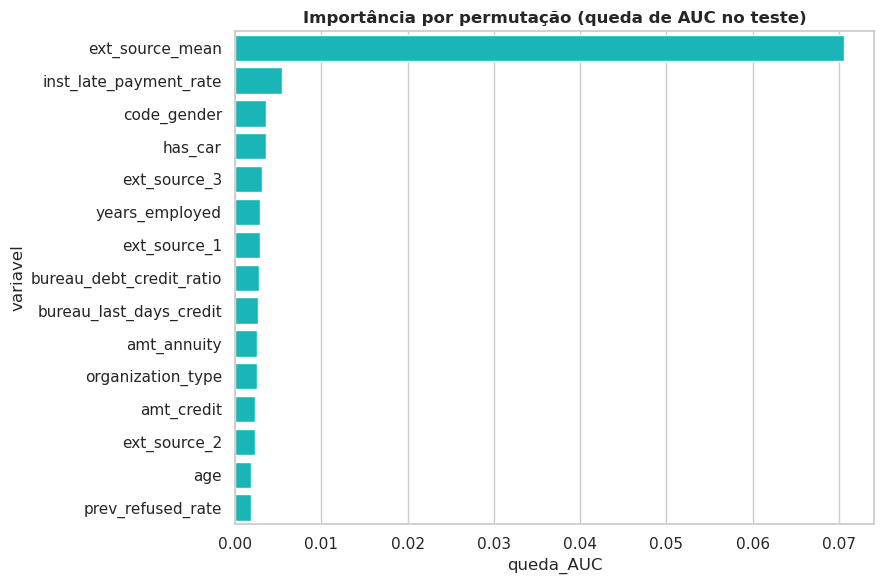

,variavel,queda_AUC
3,ext_source_mean,0.0705
35,inst_late_payment_rate,0.0055
41,code_gender,0.0036
11,has_car,0.0036
2,ext_source_3,0.0031
21,years_employed,0.0029
0,ext_source_1,0.0028
32,bureau_debt_credit_ratio,0.0027
28,bureau_last_days_credit,0.0026
19,amt_annuity,0.0026


In [9]:
amostra = X_teste.sample(n=min(15000, len(X_teste)), random_state=SEED)
y_amostra = y_teste.loc[amostra.index]
t0 = time.time()
perm = permutation_importance(modelo, amostra, y_amostra, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=-1)
print(f"Permutation importance em {time.time()-t0:.0f}s")
imp_perm = (pd.DataFrame({"variavel": amostra.columns, "queda_AUC": perm.importances_mean})
            .sort_values("queda_AUC", ascending=False).head(15))
plt.figure(figsize=(9, 6))
sns.barplot(data=imp_perm, x="queda_AUC", y="variavel", color="darkturquoise")
plt.title("Importância por permutação (queda de AUC no teste)", fontweight="bold")
plt.tight_layout(); plt.show()
imp_perm.round(4)


### **7. Interpretabilidade — valores SHAP**

Efeito e direção de cada variável. Como o modelo usa **categóricas nativas**, o `TreeExplainer` do LightGBM
lida com elas diretamente; para o color-coding do beeswarm, as categorias viram códigos numéricos.


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


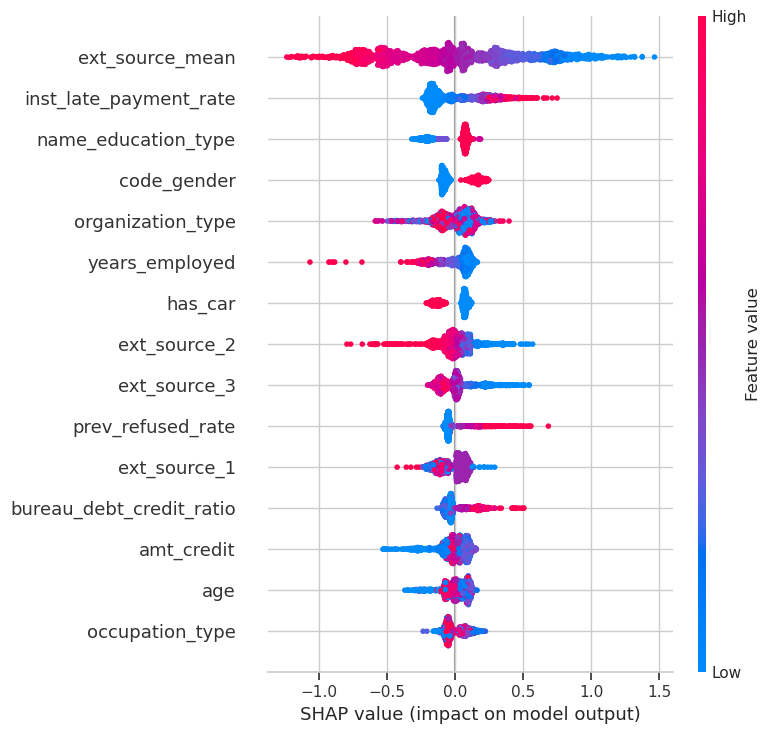

In [10]:
X_shap = X_teste.sample(n=min(2000, len(X_teste)), random_state=SEED)
try:
    explainer = shap.TreeExplainer(modelo)
    sv = explainer.shap_values(X_shap)
    if isinstance(sv, list):          # [classe_0, classe_1] em versões antigas
        sv = sv[1]
    # matriz numérica só para colorir o beeswarm (categóricas -> códigos)
    X_disp = X_shap.copy()
    for c in X_disp.select_dtypes(include="category").columns:
        X_disp[c] = X_disp[c].cat.codes
    shap.summary_plot(sv, X_disp, max_display=15, show=True)
except Exception as e:
    print("SHAP falhou:", str(e)[:200])

> ### Análise — interpretabilidade
>
> A **permutação** mede o impacto real de cada variável na AUC; o **SHAP** mostra efeito e direção.
>
> Os **`ext_source_*`** (score externo de crédito, resumidos em `ext_source_mean`)
> **dominam** a importância — coerente com o alto IV encontrado na EDA. Logo atrás vêm o histórico de
> pagamentos (`inst_late_payment_rate`) e o **`code_gender`**, seguidos de outras financeiras e demográficas
> (`ext_source_1`, `amt_credit`). A permutação é a medida de **poder preditivo** (a contagem nativa de
> *splits* pode ordenar diferente). O `code_gender` entre as mais relevantes **motiva a análise de fairness**
> a seguir.
>
> A coerência **EDA → IV → modelo** é um forte argumento de confiabilidade, e nenhuma
> variável "sem sentido de negócio" no topo → sem sinal de vazamento.

### **8. Governança e fairness**

A EDA sinalizou `code_gender` como atributo sensível. Verificamos **desempenho e política de corte por
subgrupo** para diagnosticar viés.


In [11]:
df_fair = X_teste[["code_gender"]].copy()
df_fair["y"] = y_arr
df_fair["score"] = proba_teste
df_fair["negado"] = (df_fair["score"] >= THRESHOLD).astype(int)
linhas = []
for g, sub in df_fair.groupby("code_gender", observed=True):
    l = {"grupo": g, "clientes": len(sub),
         "default_real_%": sub["y"].mean()*100, "%_negados": sub["negado"].mean()*100}
    if sub["y"].nunique() == 2:
        l["AUC_grupo"] = roc_auc_score(sub["y"], sub["score"])
        maus = sub[sub["y"] == 1]
        l["recall_%"] = maus["negado"].mean()*100 if len(maus) else np.nan
    linhas.append(l)
pd.DataFrame(linhas).round(3)


,grupo,clientes,default_real_%,%_negados,AUC_grupo,recall_%
0,F,40568,7.0570,27.2830,0.7550,63.5350
1,M,20934,10.0410,43.4320,0.7540,77.1170
2,Unknown,1,0.0000,0.0000,NaN,NaN


> ### Análise — governança e fairness
>
> O critério **RESULTS** pede diagnóstico de viés e conformidade; como o modelo pode
> usar o gênero, verificamos o impacto por subgrupo.
>
> Se o **AUC for parecido entre os grupos**, não há disparidade de **desempenho** (o
> modelo ordena bem para ambos). Uma **taxa de negados diferente** entre grupos costuma **acompanhar o
> default real** de cada um — ou seja, o modelo **reflete o dado**, não inventa o viés.


**Métricas de monitoramento em produção** (rastreabilidade / conformidade):

| Dimensão | Métrica | Alerta sugerido |
|---|---|---|
| Performance | AUC / KS por lote | queda > 10% vs. baseline do teste |
| Estabilidade dos dados | **PSI** do score e das top features | PSI > 0,25 = mudança de população |
| Decisão | taxa de aprovação e default dos aprovados/mês | desvio da meta da política |
| Calibração | Brier / curva de calibração por lote | drift sistemático do score |
| Fairness | AUC e % negados por subgrupo | divergência crescente entre grupos |


### **9. Rastreabilidade — conferência com o artefato salvo**

Carregamos o artefato produzido pelo `train.py` e conferimos que as métricas recomputadas aqui batem com
as salvas no `metrics.json` — evidência de **reprodutibilidade** (mesmo modelo, mesma seed, mesmo split).


In [12]:
import pickle

artifact_path = NB_DIR.parent / config["metadata"]["artifact"]  # .../Model/artifacts/lightgbm_abt.pkl
if artifact_path.exists():
    with open(artifact_path, "rb") as f:
        artifact = pickle.load(f)
    print("Artefato:", artifact_path.name,
          "| treinado em:", artifact.get("trained_at_utc"),
          "| config:", artifact.get("config_version"))
    print("Métricas salvas no artefato :", artifact.get("metrics"))
else:
    print("Artefato ainda não gerado. Rode antes: python Model/train.py")
print("Métricas recomputadas (holdout):", credit_metrics(y_arr, proba_teste))


Artefato: lightgbm_abt.pkl | treinado em: 2026-07-13T20:56:34+00:00 | config: 1.0.0
Métricas salvas no artefato : {'roc_auc': 0.7586, 'gini': 0.5171, 'ks': 0.3982, 'average_precision': 0.2408, 'brier': 0.1934}
Métricas recomputadas (holdout): {'roc_auc': 0.7586, 'gini': 0.5171, 'ks': 0.3982, 'average_precision': 0.2408, 'brier': 0.1934}


### **10. Conclusão**

- O **modelo desenvolvido** (LightGBM regularizado, categóricas nativas) foi avaliado no **holdout honesto**:
  **generaliza** (teste ≈ validação), com **KS de mercado** e ordenação de risco acionável (decis/lift).
- A **decisão de crédito** foi traduzida numa **política de corte em três faixas** (aprovação
  automática abaixo de 0,50, **revisão humana entre 0,50 e 0,60** e negação acima de 0,60), guiada
  pela leitura de **precisão × recall** e pelo **trade-off marginal** de bons por mau; a faixa foi
  mantida **estreita** para não sobrecarregar a análise humana (~12% da carteira).
- A **interpretabilidade** (permutação + SHAP) mostra dependência coerente com o negócio (score externo,
  idade, histórico de pagamento) — sem sinal de vazamento.
- A **governança/fairness** documenta o comportamento por subgrupo e o **plano de monitoramento** (AUC/KS,
  PSI, calibração, fairness) fecha o critério RESULTS.
- A **seleção de modelos** que justifica esta escolha está em **`validacao_modelos.ipynb`**; o **uso em nova
  base** (Etapa 10) está no **`predict.py`** e no app da etapa individual.
